# Campaign training dynamics: did every run train, and what did the penalty cost?

This notebook validates three completed training campaigns before any of their results
are interpreted, and measures how much wall time each contractive penalty configuration
adds. It answers two questions: whether every run trained without a numerical failure or
an early stop, and what the regularizer costs per epoch relative to an unregularized
baseline.

It is a precondition for `part_1` (prediction) and `part_2` (latent geometry): a cell
whose runs failed must not be read as a result, and a cost difference of several times
baseline is itself part of any decision about which penalty to adopt. No model weights
are loaded here; everything is read from the campaigns' recorded training histories.

## Introduction

Three campaigns are pooled. The baseline trains a reconstruction and a classification
head with no contractive regularization. The first sweep varies the penalty metric and
weight under the Euclidean input geometry. The second varies them under the Fisher-Rao
input geometry on the TIC simplex, with an additional combined spectral-plus-hinge
penalty. Pooling them is only meaningful because the architecture, binning, dataset
subset, split strategy, seeds and head configuration are identical across all three.

### Assumptions

- **Run comparability.** All three campaigns share `bin_step=0.55`, the same
  `proportional_multilabel` split at fractions 0.8/0.1/0.1, the same subset fraction
  0.1 with seed 42, the same architecture, and the same split and dataloader seeds. Only
  the `regularization.contractive` term differs. If any of these had drifted, the
  duration and loss comparisons below would confound the penalty with a data change.
- **Timing is wall-clock on shared hardware.** Epoch durations were recorded on compute
  nodes whose load is not controlled by this analysis. Between-repetition spread
  therefore contains machine contention as well as genuine algorithmic cost. The
  comparison is only trustworthy because it is consistent across five repetitions and
  across weights within a penalty family, which contention would not reproduce.
- **The recorded penalty value is the criterion's own output**, on its own scale. Values
  of the contractive term are not comparable between input geometries: the Fisher-Rao
  operator carries the scale of the TIC-normalized spectrum. Only the *direction* of
  change within one run is read here, never the level across geometries.
- **Health checks are necessary, not sufficient.** A run that passes every check below
  can still have converged to a useless representation; that question belongs to
  `part_1` and `part_2`.

### Notation

Let $\mathrm{Enc}$ denote the encoder, $J$ its input-output Jacobian, and $u$ the
canonicalized latent that the penalty is applied in. One *grid cell* is a configuration
$c = (\text{geometry}, \text{penalty metric}, \lambda)$, where $\lambda$ is the
objective weight of the contractive term. Each cell is trained in $R = 5$ repetitions
indexed by $r$, differing only in run seeds. For run $(c, r)$, write $P_e(c,r)$ for the
recorded contractive term at epoch $e$ and $T_e(c,r)$ for that epoch's wall-clock
duration in seconds.

In [1]:
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("campaign_training_dynamics")

2026-09-06 23:50:28,597 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-06 23:50:28,600 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


## Configuration

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE = WORKSPACE / "models" / MODEL_CONTEXT

CAMPAIGNS = {
    "fischer-rao-spectral-hinge-experiment-20260906-01": "Fisher-Rao sweep",
    "contractive-20260905-01": "Euclidean sweep",
    "bce-baseline-20260905-01": "baseline",
}
PLANNED_EPOCHS = 15

ARTIFACT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_0_2_campaign_training_dynamics_results")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()


def status_directory(campaign_id: str) -> Path:
    return WORKSPACE / "configs" / "entropy-runs" / campaign_id / "plan" / "status"


grid_rows, dynamics_rows, evaluation_rows = [], [], []
for campaign_id in CAMPAIGNS:
    tasks = read_entropy_campaign(status_directory(campaign_id), MODEL_STORE, load_artifacts=True)
    grid_rows += sweep.sweep_grid_frame(tasks, campaign_id)
    dynamics_rows += sweep.training_dynamics_frame(tasks, campaign_id)
    evaluation_rows += sweep.final_evaluation_frame(tasks, campaign_id)

grid_frame = pd.DataFrame(grid_rows)
dynamics_frame = pd.DataFrame(dynamics_rows)
evaluation_frame = pd.DataFrame(evaluation_rows)
print(f"{len(grid_frame)} task(s), {len(dynamics_frame)} per-epoch objective row(s)")

2026-09-06 23:50:28,953 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 75 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status'.


2026-09-06 23:50:31,221 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/fischer-rao-spectral-hinge-experiment-20260906-01/plan/status': 75 task(s) read.


2026-09-06 23:50:31,222 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:212 | Campaign 'fischer-rao-spectral-hinge-experiment-20260906-01': 75 task(s), 75 completed, 15 distinct grid cell(s).


2026-09-06 23:50:31,240 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:300 | Campaign 'fischer-rao-spectral-hinge-experiment-20260906-01': built 9000 per-epoch objective row(s) from 75 task(s).


2026-09-06 23:50:31,242 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:356 | Campaign 'fischer-rao-spectral-hinge-experiment-20260906-01': 300 post-training evaluation row(s).


...

2026-09-06 23:50:33,165 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


2026-09-06 23:50:33,238 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:212 | Campaign 'bce-baseline-20260905-01': 5 task(s), 5 completed, 1 distinct grid cell(s).


2026-09-06 23:50:33,239 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:300 | Campaign 'bce-baseline-20260905-01': built 450 per-epoch objective row(s) from 5 task(s).


2026-09-06 23:50:33,240 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:356 | Campaign 'bce-baseline-20260905-01': 15 post-training evaluation row(s).


140 task(s), 16650 per-epoch objective row(s)


## Grid coverage

### Methodology

#### Theoretical

Every downstream comparison assumes each grid cell contributes the same number of
repetitions. A cell short of repetitions is not merely noisier: pooled statistics
across cells become weighted by an accident of which runs finished. This section
establishes the realized design before anything is compared.

#### Implementation

`sweep_grid_frame` emits one record per task regardless of status, so incomplete or
failed tasks stay visible. Cell identity is resolved by `sweep_cell`, which reads
`objectives.regularization.contractive` from the task manifest and falls back to the
`ContractiveLoss` constructor defaults for parameters a campaign predates. The Euclidean
sweep predates `input_geometry`, so it resolves to `euclidean`, the constructor default,
rather than to an unknown value; that is what makes the two sweeps poolable on one axis.

#### Figure descriptions

The table lists one row per grid cell. Columns are the input geometry, penalty metric,
objective weight and hinge threshold that define the cell, the number of tasks in it,
and the set of terminal statuses those tasks reached. A complete design has the same
task count in every row and `completed` as the only status.

### Remarks

### Notes

In [3]:
coverage = (
    grid_frame
    .groupby(["campaign", "input_geometry", "penalty_metric", "weight", "hinge_threshold"], dropna=False)
    .agg(tasks=("task_id", "size"), statuses=("status", lambda values: "/".join(sorted(set(values)))))
    .reset_index()
)
display(coverage)

incomplete = coverage[(coverage["statuses"] != "completed") | (coverage["tasks"] != coverage["tasks"].max())]
print("cells with an incomplete design:", len(incomplete))

,campaign,input_geometry,penalty_metric,weight,hinge_threshold,tasks,statuses
0,bce-baseline-20260905-01,euclidean,none,NaN,NaN,5,completed
1,contractive-20260905-01,euclidean,frobenius,0.00001,NaN,5,completed
2,contractive-20260905-01,euclidean,frobenius,0.00010,NaN,5,completed
3,contractive-20260905-01,euclidean,frobenius,0.00100,NaN,5,completed
4,contractive-20260905-01,euclidean,frobenius,0.01000,NaN,5,completed
5,contractive-20260905-01,euclidean,hinged,0.00001,400.0,5,completed
6,contractive-20260905-01,euclidean,hinged,0.00010,400.0,5,completed
7,contractive-20260905-01,euclidean,hinged,0.00100,400.0,5,completed
8,contractive-20260905-01,euclidean,hinged,0.01000,400.0,5,completed
9,contractive-20260905-01,euclidean,spectral,0.00001,NaN,5,completed


cells with an incomplete design: 0


## Training validity per run

### Methodology

#### Theoretical

Four independent failure modes would each invalidate a run's results in a different way,
and none of them is visible in a final metric alone:

1. a non-finite objective value at any epoch means the optimizer left the valid region
   and every later epoch is meaningless;
2. a contractive term whose final training value exceeds its first means the penalty was
   not minimized, which at large $\lambda$ indicates the objective is dominated by a term
   the optimizer cannot reduce;
3. fewer epochs than the configured budget means early stopping or a crash, so the run is
   not comparable to a full-length one;
4. no improving checkpoint after the first epoch means the restored best model is the
   first epoch's, so the run effectively did not train.

Formally, run $(c,r)$ is flagged as unhealthy if any of
$\exists e: \neg\mathrm{finite}(P_e)$, $P_{E}>P_{1}$, $E < E_{\mathrm{planned}}$, or
$\nexists e>1$ with an improving checkpoint, where $E$ is the measured epoch count.

#### Implementation

`training_health_report` computes all four checks from the per-epoch records, keyed by
`model_name` rather than `task_id` because task identifiers restart at `task_000000` in
every campaign and would otherwise merge runs from different campaigns. Tasks whose
artifacts are absent are emitted as zero-epoch unhealthy records rather than silently
dropped, so a partially synchronized campaign cannot read as fully healthy. The penalty
check is applied to the training-split contractive series; baseline runs have no such
term and are exempt from it by construction.

#### Figure descriptions

The first table counts flagged runs per campaign: one column per check plus the count of
runs passing all four. Zero in every check column and a `healthy` count equal to the
campaign's run count is the passing outcome. The second table, printed only when
something failed, lists each flagged run with its cell label, repetition, measured epoch
count and first and final penalty values.

### Remarks

### Notes

In [4]:
health_frame = pd.DataFrame(sweep.training_health_report(dynamics_rows, grid_rows, planned_epochs=PLANNED_EPOCHS))
check_columns = ["non_finite_objectives", "penalty_increased", "short_run", "no_improvement", "healthy"]
display(health_frame.groupby("campaign")[check_columns].sum())

unhealthy = health_frame[~health_frame["healthy"]]
if len(unhealthy):
    display(unhealthy[["campaign", "cell_label", "repetition", "epochs", "first_penalty", "final_penalty", *check_columns[:-1]]])
else:
    print(f"All {len(health_frame)} run(s) passed every check.")

2026-09-06 23:50:33,313 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:664 | All 140 run(s) passed the training health checks.


,non_finite_objectives,penalty_increased,short_run,no_improvement,healthy
campaign,,,,,
bce-baseline-20260905-01,0,0,0,0,5
contractive-20260905-01,0,0,0,0,60
fischer-rao-spectral-hinge-experiment-20260906-01,0,0,0,0,75


All 140 run(s) passed every check.


## Penalty trajectory within each run

### Methodology

#### Theoretical

The health check above only asks whether the penalty decreased between the first and
last epoch. Its trajectory carries more: a penalty that collapses within one epoch and
then sits flat indicates the constraint became inactive, while one that decreases
steadily throughout indicates it remained binding for the whole run. Since $P$ is on a
geometry-specific scale, each run is normalized by its own first-epoch value,
$\tilde P_e = P_e / P_1$, which makes the *shape* comparable across geometries while
discarding the level, which is not.

#### Implementation

Training-split `contractive` rows are divided by their own run's epoch-1 value. Every
repetition is drawn as its own line at low opacity rather than as a mean curve, so a
single divergent repetition inside an otherwise well-behaved cell stays visible. Weights
are drawn in one panel per penalty family, with color encoding $\lambda$ on a
logarithmic scale.

#### Figure descriptions

One panel per (geometry, penalty metric) family. The x-axis is the training epoch, the
y-axis the contractive term normalized to its own first epoch, on a logarithmic scale.
Each thin line is one repetition of one weight; color encodes $\lambda$, darker meaning
larger. The dotted horizontal line at 1 marks the first-epoch level: a line below it has
reduced the penalty, one above it has increased it. Lines that flatten early indicate the
penalty stopped being the binding constraint.

### Remarks

### Notes

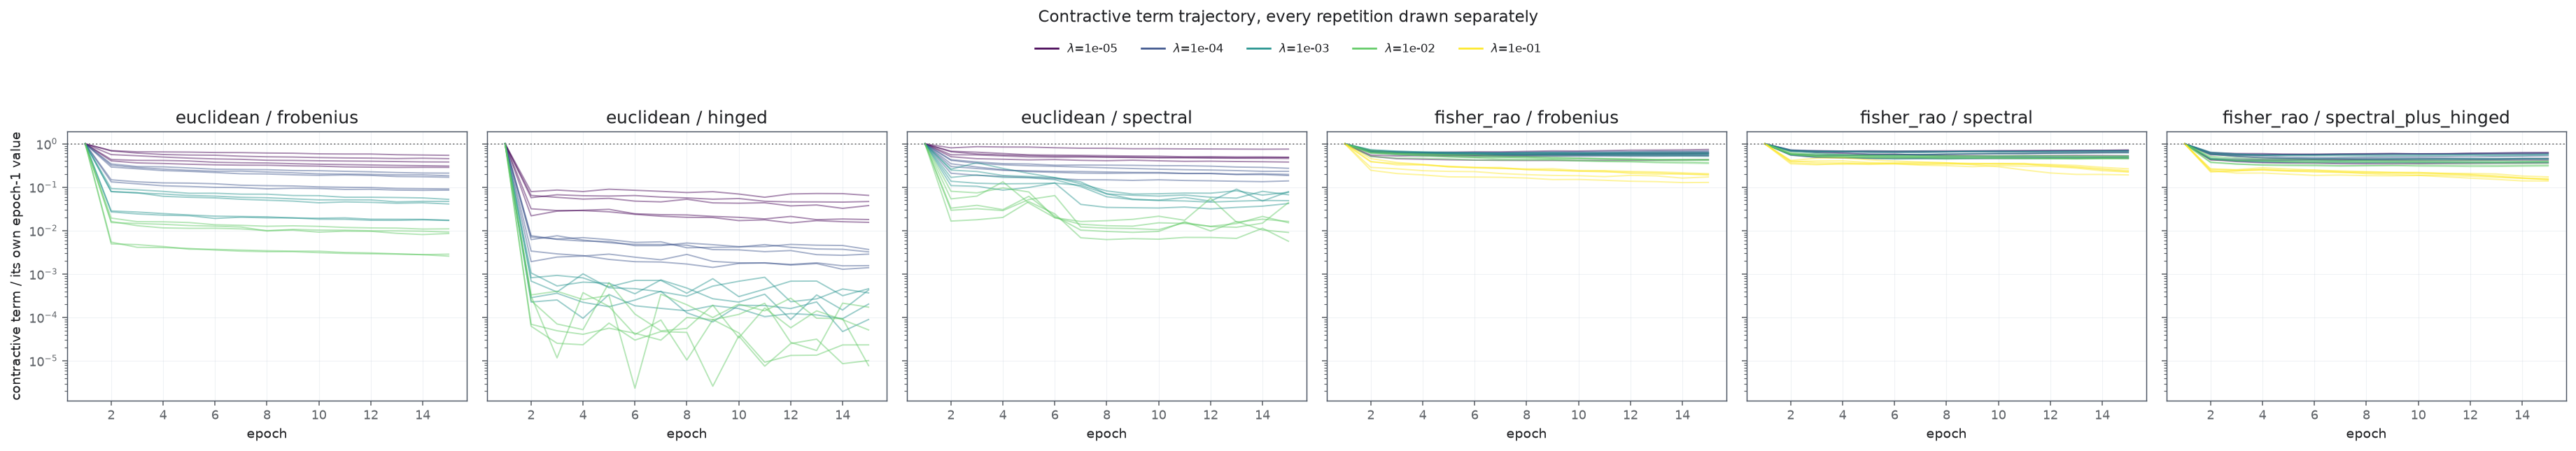

In [5]:
penalty_curves = dynamics_frame.query("objective == 'contractive' and split == 'train'").copy()
first_epoch = penalty_curves.query("epoch == 1").set_index("model_name")["value"]
penalty_curves["normalized"] = penalty_curves["value"] / penalty_curves["model_name"].map(first_epoch)

families = penalty_curves.groupby(["input_geometry", "penalty_metric"]).size().index.tolist()
figure, axes = plt.subplots(1, len(families), figsize=(4.4 * len(families), 4.0), dpi=theme.figure_dpi, sharey=True)
weights = sorted(penalty_curves["weight"].dropna().unique())
weight_color = {weight: plt.cm.viridis(index / max(len(weights) - 1, 1)) for index, weight in enumerate(weights)}

for axis, (geometry, metric) in zip(np.atleast_1d(axes), families):
    family = penalty_curves.query("input_geometry == @geometry and penalty_metric == @metric")
    for (model_name, weight), run in family.groupby(["model_name", "weight"]):
        axis.plot(run["epoch"], run["normalized"], color=weight_color[weight], alpha=0.45, linewidth=1.0)
    axis.axhline(1.0, color="grey", linestyle=":", linewidth=1)
    axis.set_yscale("log")
    axis.set(xlabel="epoch", title=f"{geometry} / {metric}")
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
np.atleast_1d(axes)[0].set_ylabel(r"contractive term / its own epoch-1 value")
handles = [plt.Line2D([], [], color=weight_color[weight], label=f"$\\lambda$={weight:.0e}") for weight in weights]
figure.legend(handles=handles, loc="upper center", ncol=len(weights), frameon=theme.legend_frame, bbox_to_anchor=(0.5, 1.08))
figure.suptitle("Contractive term trajectory, every repetition drawn separately", y=1.14)
figure.tight_layout()

## Wall-clock cost of each penalty configuration

### Methodology

#### Theoretical

The regularizer's cost is a decision criterion, not an implementation detail: a penalty
that doubles training time must earn that. Cost is driven by how the Jacobian
information is obtained, not by the weight $\lambda$, which only scales an already
computed quantity. That gives a built-in validity check: within one penalty family,
duration must be flat in $\lambda$. If it is not, the measurement is picking up machine
contention rather than algorithmic cost.

Per-epoch duration $T_e(c,r)$ is treated as the observation unit and pooled over epochs
and repetitions within a cell. The reference is the mean baseline epoch duration
$\bar T_{\mathrm{base}}$, and the reported ratio is $\bar T_c / \bar T_{\mathrm{base}}$.

#### Implementation

`training_dynamics_frame` emits one row per objective term per epoch, so the same epoch's
duration appears several times; `run_duration_frame` and `epoch_duration_samples`
deduplicate on `(model_name, epoch)` before any reduction. Failing to do so would
multiply every reported duration by the number of objective terms. Durations come from
the trainer's own per-epoch `duration` field and include the forward pass, backward pass,
optimizer step and validation pass.

#### Figure descriptions

The table reports, per cell, the mean and standard deviation of individual epoch
durations in seconds, the mean total duration of one complete run, and the ratio of the
cell's mean epoch duration to the baseline's. The violin plot shows the full distribution
of individual epoch durations for every cell, with each measured epoch drawn as a point
over the violin; the dotted horizontal line marks the baseline mean. The x-axis groups
cells by penalty family, the y-axis is seconds per epoch. Wider violins indicate more
variable epoch cost, which for a fixed algorithm reflects machine contention.

### Remarks

### Notes

In [6]:
run_frame = pd.DataFrame(sweep.run_duration_frame(dynamics_rows))
baseline_epoch_seconds = run_frame.query("penalty_metric == 'none'")["mean_epoch_duration"].mean()

duration_summary = (
    run_frame
    .groupby(["input_geometry", "penalty_metric", "calculation_method", "weight"], dropna=False)
    .agg(
        mean_epoch_seconds=("mean_epoch_duration", "mean"),
        std_epoch_seconds=("mean_epoch_duration", "std"),
        mean_total_seconds=("total_duration", "mean"),
        runs=("model_name", "size"),
    )
    .reset_index()
)
duration_summary["times_baseline"] = duration_summary["mean_epoch_seconds"] / baseline_epoch_seconds
print(f"baseline mean epoch duration: {baseline_epoch_seconds:.1f} s")
display(duration_summary.round(2))

2026-09-06 23:50:35,167 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:415 | Reduced per-epoch rows to 140 run duration record(s).


baseline mean epoch duration: 28.4 s


,input_geometry,penalty_metric,calculation_method,weight,mean_epoch_seconds,std_epoch_seconds,mean_total_seconds,runs,times_baseline
0,euclidean,frobenius,approximate_hutchinson_vjp,0.00,52.64,2.49,789.61,5,1.85
1,euclidean,frobenius,approximate_hutchinson_vjp,0.00,54.59,2.97,818.82,5,1.92
2,euclidean,frobenius,approximate_hutchinson_vjp,0.00,54.76,3.21,821.41,5,1.93
3,euclidean,frobenius,approximate_hutchinson_vjp,0.01,53.57,3.12,803.57,5,1.89
4,euclidean,hinged,approximate_hutchinson_vjp,0.00,54.31,3.53,814.59,5,1.91
5,euclidean,hinged,approximate_hutchinson_vjp,0.00,53.89,3.06,808.32,5,1.90
6,euclidean,hinged,approximate_hutchinson_vjp,0.00,52.66,3.03,789.84,5,1.85
7,euclidean,hinged,approximate_hutchinson_vjp,0.01,55.54,1.95,833.12,5,1.96
8,euclidean,none,NaN,NaN,28.40,1.45,426.00,5,1.00
9,euclidean,spectral,approximate_hutchinson_vjp,0.00,57.60,1.27,863.99,5,2.03


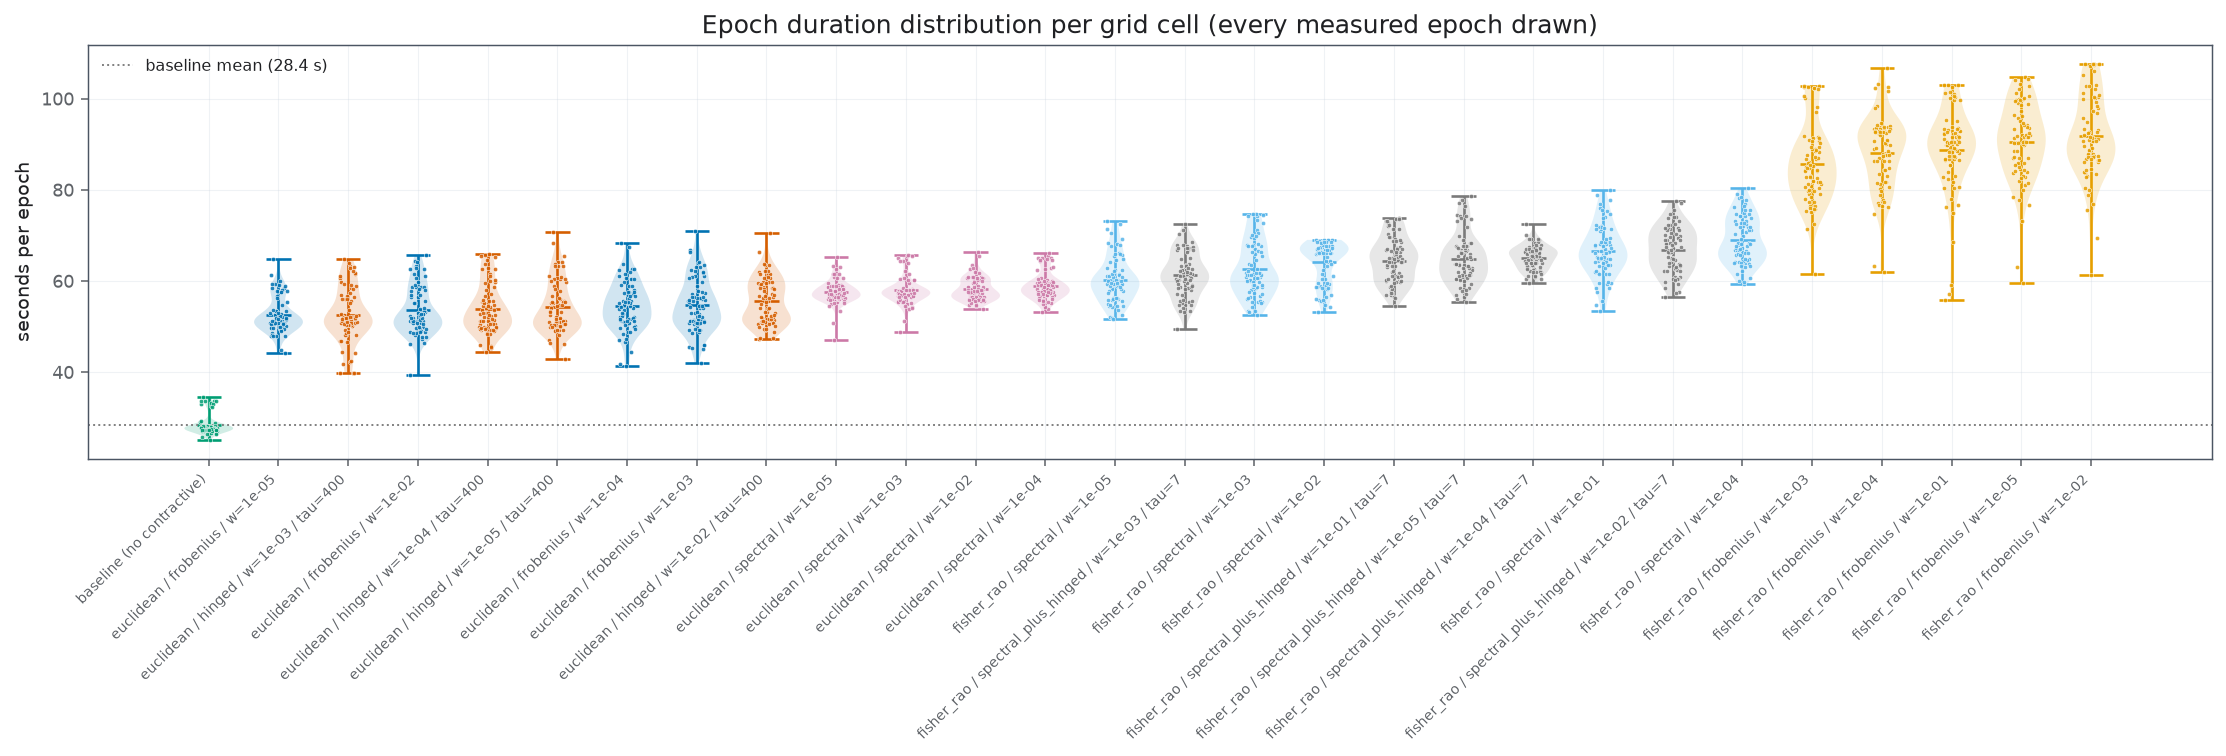

In [7]:
duration_samples = sweep.epoch_duration_samples(dynamics_rows)
ordered_cells = (
    run_frame.groupby("cell_label")["mean_epoch_duration"].mean().sort_values().index.tolist()
)
family_of = run_frame.drop_duplicates("cell_label").set_index("cell_label")[["input_geometry", "penalty_metric"]]
families = sorted({tuple(family_of.loc[cell]) for cell in ordered_cells})
family_color = {family: theme.color_for_model("/".join(family), index) for index, family in enumerate(families)}

figure, ax = plt.subplots(figsize=(16.0, 5.5), dpi=theme.figure_dpi)
for position, cell in enumerate(ordered_cells):
    plot_violin_with_points(
        np.asarray(duration_samples[cell]), position=position, ax=ax, width=0.7,
        color=family_color[tuple(family_of.loc[cell])], point_size=5.0, jitter=0.12, theme=theme,
    )
ax.axhline(baseline_epoch_seconds, color="grey", linestyle=":", linewidth=1, label=f"baseline mean ({baseline_epoch_seconds:.1f} s)")
ax.set_xticks(range(len(ordered_cells)))
ax.set_xticklabels(ordered_cells, rotation=45, ha="right", fontsize=7)
ax.set(ylabel="seconds per epoch", title="Epoch duration distribution per grid cell (every measured epoch drawn)")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Declared estimator against measured cost

### Methodology

#### Theoretical

The campaign configuration declares a `calculation_method` per cell, which is expected to
determine how Jacobian information is obtained and therefore the cost. Checking the
declaration against the measurement tests whether the configuration surface actually
describes what runs. A discrepancy means the declared parameter is inert for some
penalties, which matters when planning a campaign's compute budget from its configuration
alone.

Exact reverse-mode accumulation costs one backward pass per latent coordinate, so $D$
passes for latent dimension $D$. A spectral norm obtained by power iteration costs a fixed
small number of passes independent of $D$. The two therefore separate whenever $D$ exceeds
that fixed number.

#### Implementation

Mean epoch durations are grouped by the declared `calculation_method` and the penalty
metric. The latent dimension is read from the campaign configuration, and the power
iteration step count from the criterion module's own constant, so the expected ratio is
derived from the implementation rather than assumed.

#### Figure descriptions

The table reports mean epoch duration and mean total run duration grouped by declared
estimator and penalty metric. If the declaration determined cost, rows sharing an
estimator would agree. Rows that disagree identify penalties whose cost the declaration
does not describe.

### Remarks

### Notes

In [8]:
from msi_autoencoder_wrapper.training.criterions.autoencoder.regularization import contractive_loss as criterion_module

estimator_summary = (
    run_frame
    .groupby(["calculation_method", "penalty_metric"], dropna=False)
    .agg(
        mean_epoch_seconds=("mean_epoch_duration", "mean"),
        std_epoch_seconds=("mean_epoch_duration", "std"),
        mean_total_seconds=("total_duration", "mean"),
        runs=("model_name", "size"),
    )
    .round(1)
)
display(estimator_summary)

latent_dimension = grid_frame.attrs.get("latent_dimension", 10)
power_iteration_steps = criterion_module._SPECTRAL_POWER_ITERATION_STEPS
print(f"latent dimension D = {latent_dimension}; spectral power-iteration steps = {power_iteration_steps}")
print(f"exact accumulation needs D = {latent_dimension} backward passes, power iteration needs {power_iteration_steps}")

2026-09-06 23:50:36,171 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-06 23:50:36,172 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-06 23:50:36,174 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-06 23:50:36,175 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-06 23:50:36,186 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-06 23:50:36,195 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 21 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-06 23:50:36,197 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 25 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


mean_epoch_seconds  \
calculation_method         penalty_metric                             
approximate_hutchinson_vjp frobenius                           53.9   
                           hinged                              54.1   
                           spectral                            58.2   
exact_autograd_jacobian    frobenius                           88.9   
                           spectral                            64.5   
                           spectral_plus_hinged                64.5   
NaN                        none                                28.4   

                                                 std_epoch_seconds  \
calculation_method         penalty_metric                            
approximate_hutchinson_vjp frobenius                           2.9   
                           hinged                              2.9   
                           spectral                            2.1   
exact_autograd_jacobian    frobenius                           6.3   
                           spectral                            5.0   
                           spectral_plus_hinged                4.0   
NaN                        none                                1.5   

                                                 mean_total_seconds  runs  
calculation_method         penalty_metric                                  
approximate_hutchinson_vjp frobenius                          808.4    20  
                           hinged                             811.5    20  
                           spectral                           872.9    20  
exact_autograd_jacobian    frobenius                         1334.2    25  
                           spectral                           967.8    25  
                           spectral_plus_hinged               968.2    25  
NaN                        none                               426.0     5

latent dimension D = 10; spectral power-iteration steps = 3
exact accumulation needs D = 10 backward passes, power iteration needs 3


## Reproducible artifacts

### Methodology

#### Implementation

Every table above is persisted in long form so the figures can be regenerated without
re-reading the campaigns, together with provenance sufficient to identify what produced
them: campaign identifiers, the planned epoch budget, library versions, the current
commit and a hash of the criterion source whose behavior the timing measures.

### Remarks

### Notes

In [9]:
import hashlib

frames = {
    "grid_coverage": grid_frame,
    "training_dynamics": dynamics_frame,
    "final_evaluation": evaluation_frame,
    "training_health": health_frame,
    "run_durations": run_frame,
    "duration_summary": duration_summary,
}
for name, frame in frames.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)

criterion_path = Path("src/msi_autoencoder_wrapper/training/criterions/autoencoder/regularization/contractive_loss.py")
metadata = {
    "campaigns": CAMPAIGNS,
    "planned_epochs": PLANNED_EPOCHS,
    "runs": int(len(run_frame)),
    "baseline_mean_epoch_seconds": float(baseline_epoch_seconds),
    "healthy_runs": int(health_frame["healthy"].sum()),
    "total_runs": int(len(health_frame)),
    "spectral_power_iteration_steps": int(power_iteration_steps),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "git_commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip(),
    "criterion_sha256": hashlib.sha256(criterion_path.read_bytes()).hexdigest(),
    "analysis_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/analysis/autoencoder/experiments/penalty_sweep.py").read_bytes()).hexdigest(),
}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
logger.info("Wrote %s table(s) and provenance to %s", len(frames), ARTIFACT_DIR)
print(sorted(path.name for path in ARTIFACT_DIR.iterdir()))

2026-09-06 23:50:36,437 | INFO     | campaign_training_dynamics:30 | Wrote 6 table(s) and provenance to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_0_2_campaign_training_dynamics_results


['duration_summary.csv', 'final_evaluation.csv', 'grid_coverage.csv', 'metadata.json', 'run_durations.csv', 'training_dynamics.csv', 'training_health.csv']


## Results / Summary

### LLM

**Every run in all three campaigns is usable.** 140 runs (75 Fisher-Rao, 60 Euclidean, 5
baseline) each completed the full 15-epoch budget, recorded no non-finite objective value,
reduced their contractive term between the first and last epoch, and improved their
validation checkpoint after the first epoch. No cell is excluded from the downstream
analyses on validity grounds.

**The penalty roughly doubles to triples epoch cost, and the cost ordering is not the one
the configuration implies.** Against a baseline of 28.4 seconds per epoch: the Euclidean
Hutchinson penalties cost 1.85 to 2.07 times baseline, the Fisher-Rao spectral and
spectral-plus-hinge penalties 2.27 times, and the Fisher-Rao Frobenius penalty 3.13 times.

**Observed result, with an implementation explanation.** Every cell of the Fisher-Rao
campaign declares `calculation_method: exact_autograd_jacobian`, yet its spectral cells
cost 64.5 seconds per epoch against 88.9 for its Frobenius cells. The declaration
therefore does not describe the cost of 10 of the 15 cells. The reason is in the criterion
itself: the spectral norm is obtained by a fixed three-step power iteration
(`_SPECTRAL_POWER_ITERATION_STEPS`) regardless of the declared method, while exact
Frobenius accumulates one backward pass per latent coordinate, so $D=10$ passes. The most
expensive configuration in this campaign is exact Frobenius, not the spectral one, which
is the opposite of the intuition that a spectral norm is the harder quantity.

**Evidence that the timing is algorithmic rather than machine noise.** Within every penalty
family the duration is flat across four to five decades of $\lambda$, which a weight cannot
affect since it only scales an already computed penalty. Contention would not reproduce
that pattern across five repetitions and every weight.

**Methodological note affecting cross-campaign reading.** The recorded contractive value is
on a geometry-specific scale, so its level is not comparable between the Euclidean and
Fisher-Rao arms. Only its within-run direction is read here; any cross-arm comparison of
regularization strength must use a measured quantity, which `part_2` provides as realized
angular sensitivity.

**Prediction from the campaign benchmark.** The pre-registered projection estimated the new
campaign at 1.435 times the previous campaign's wall time. The realized ratio over summed
run durations is 1.53, so the projection was accurate and conservative in the safe
direction.

### Person